## Starting with a focus on the WEEKLY dataset
### As shown in the Prophet model we saw significant improvements in Weekly Aggregation


In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

## Introduce the dataset with the Date columns "parsed":

The parameter settings parsed are:

index_col = 'dt' Set the new datetime format column as the index

na_values=['nan','?'] Allows any occurences of 'nan' or '?' to be recognised as NaN.

parse_dates = [0] Specifies the index of the column that has to be parsed as datetime.

In [2]:
df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx",  index_col='Date', parse_dates=["Date"])
df.drop(columns = 'Unnamed: 0', inplace =True)
df =df.drop(columns = ['Daily range degC',
                       'Grass min °C',
                       'Rainfall mm raw incl traces',
                      'Tmax °C',
                       'Tmin °C',
                       'Max ≥ 25.0°C',	
                        'Max ≥ 30.0°C'	,
                        'Min ≥ 15.0 °C'	,
                        'Max < 0 °C',
                       'Rain day (0.2 mm or more)',
                       'Wet day (1.0 mm or more)'
                      ])
#df = df[df['Date']<'2025-12-31']
df = df.loc[:'2025-12-31']
df.tail(3)


,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Rainfall mm 1 dpl no traces,Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,
2025-12-29,5.2,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2025-12-30,4.4,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2025-12-31,8.1,0.0,0.0,0.9,0.0,1.0,0.0,NaN


This dataset contains multivariate time series data describeing the weather conditions and Incident_count per day. 

It spans January 2015 to December 2025, with the data recorded at dailyintervals.

Before beginning any analysis we need to explore the data and ensure it is clean and in a suitable format.

Let's first check the data types to be sure they are in the correct format

In [3]:
df.dtypes

Daily Tmean °C                 float64
Air frost 0/1                  float64
Ground frost 0/1               float64
Rainfall mm 1 dpl no traces    float64
Sunshine duration h            float64
Nil sunshine                   float64
12 h sunshine                  float64
Incident_Count                 float64
dtype: object

## Clean the data

In [4]:
sum_nans = df.isna().sum()
sum_nans

Daily Tmean °C                  4
Air frost 0/1                   0
Ground frost 0/1               37
Rainfall mm 1 dpl no traces     0
Sunshine duration h             0
Nil sunshine                    0
12 h sunshine                   0
Incident_Count                  1
dtype: int64

In [5]:
df = df.ffill()
df = df.astype(float)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4018 entries, 2015-01-01 to 2025-12-31
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Daily Tmean °C               4018 non-null   float64
 1   Air frost 0/1                4018 non-null   float64
 2   Ground frost 0/1             4018 non-null   float64
 3   Rainfall mm 1 dpl no traces  4018 non-null   float64
 4   Sunshine duration h          4018 non-null   float64
 5   Nil sunshine                 4018 non-null   float64
 6   12 h sunshine                4018 non-null   float64
 7   Incident_Count               4018 non-null   float64
dtypes: float64(8)
memory usage: 282.5 KB


In [6]:
sum_nans2 = df.isna().sum()
sum_nans2

Daily Tmean °C                 0
Air frost 0/1                  0
Ground frost 0/1               0
Rainfall mm 1 dpl no traces    0
Sunshine duration h            0
Nil sunshine                   0
12 h sunshine                  0
Incident_Count                 0
dtype: int64

Visualise the data
We can now begin to visualise the data and decide on the problem we would like to investigate.

4. What is the shape of the dataframe df?

Store your answer in a variable called df_shape**

In [7]:
df_shape = df.shape
df_shape

(4018, 8)

#### As the data is recorded at daily intervals, this means we have a very large dataset with noise. 
##### With such precise time series data, it can be useful to downsample the activity to  weekly or even monthly data.

In [87]:
daily_total = df#.resample('D').sum()
daily_mean =  df#.resample('D').mean()

In [88]:
def plot_dataframe(dataframe):
    '''
    This function takes in a pandas dataframe and plots data for all columns provided in a grid of size n_rowsx2,
    where n_rows is ceil(cols/2) and cols is the number of provided columns in the dataframe.
    '''
    # Get the number of columns
    cols = dataframe.shape[1]
    
    # Create a figure of suitable size
    n_rows = int(np.ceil(cols/2))
    n_cols = 2
    fig, axs = plt.subplots(n_rows, n_cols, figsize = (30, 25));
    
    # Set the titles to be those of the dataframe variable names 
    columns = dataframe.columns
    
    # In each position, plot the relevant data
    counter = 0
    
    # If we have an odd number of subplots to make, do the last one separately
    if cols%2 != 0:
        n_rows -= 1
        axs[n_rows, 0].plot(dataframe[columns[-1]]);
        axs[n_rows, 0].set_title(columns[-1], fontweight = 'bold', size = 20);
        fig.delaxes(axs[n_rows, 1])  
        
    # Do the remaining plots 
    for i in range(n_rows):
        for j in range(n_cols):
            axs[i, j].plot(dataframe[columns[counter]]);
            axs[i, j].set_title(columns[counter], fontweight = 'bold', size = 20);
            counter += 1
    # Show the plot
    plt.show()
    return 
    

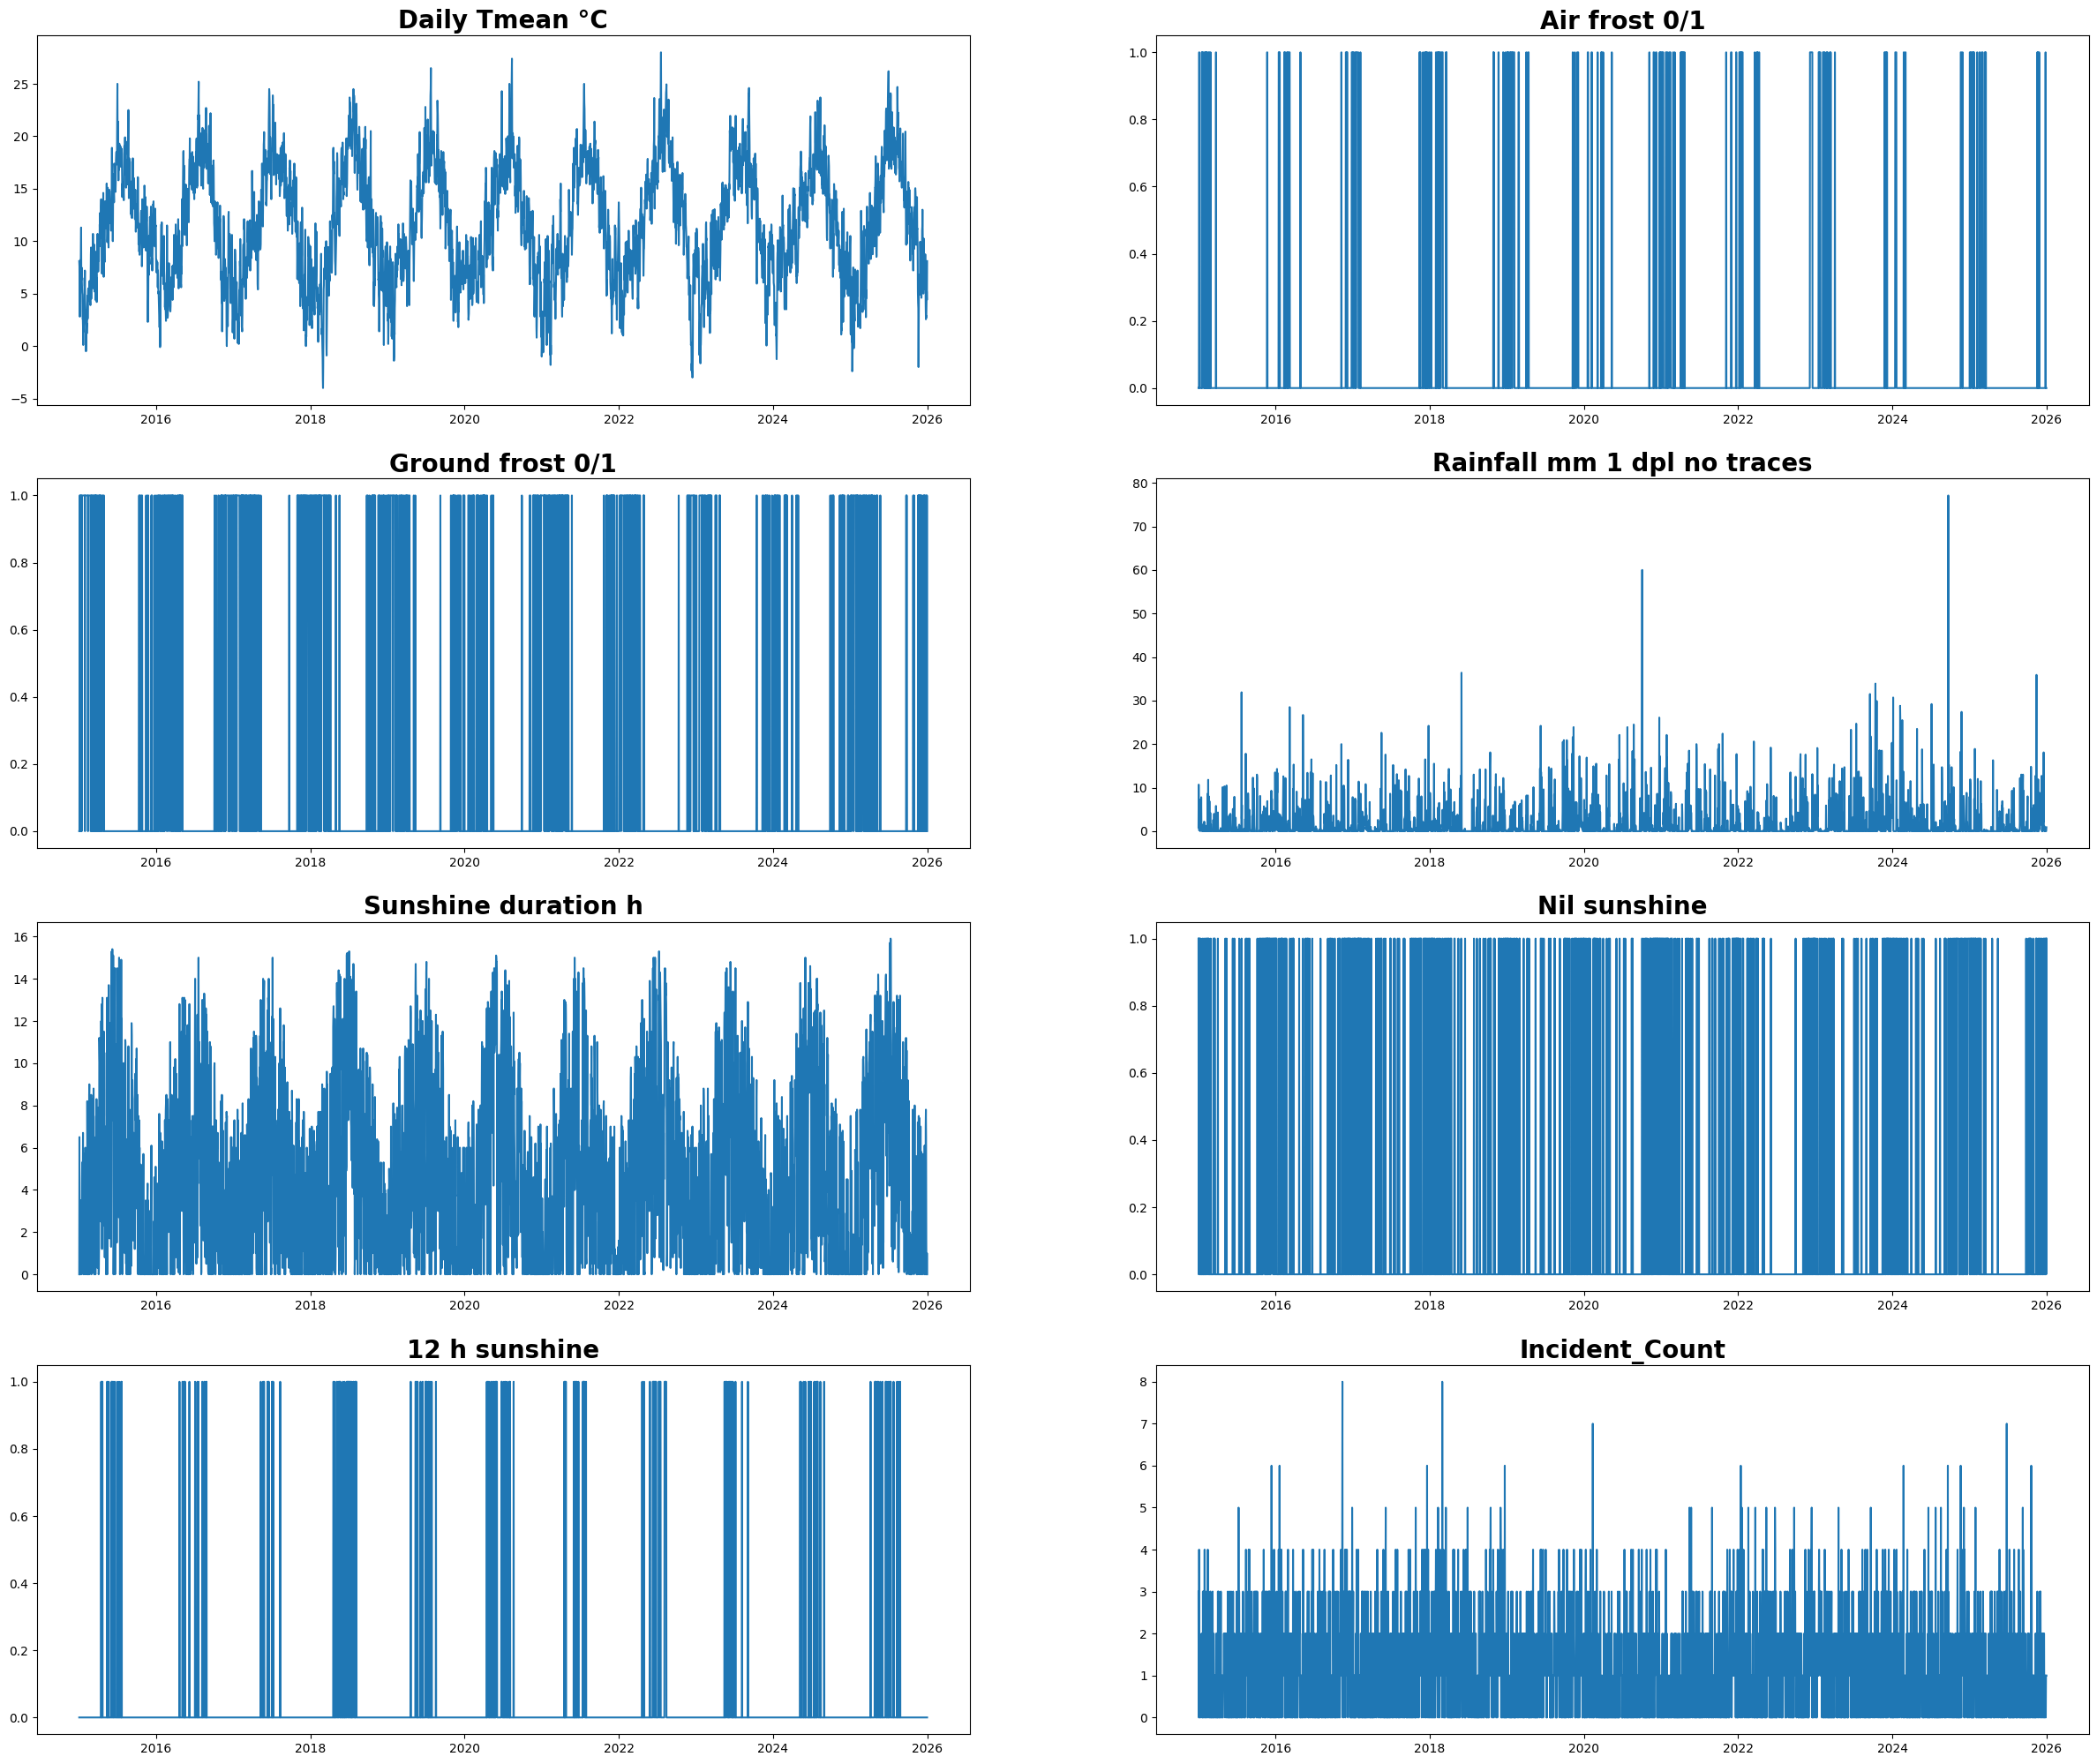

In [89]:
mean_daily_plot = plot_dataframe(daily_mean.iloc[:,0:])

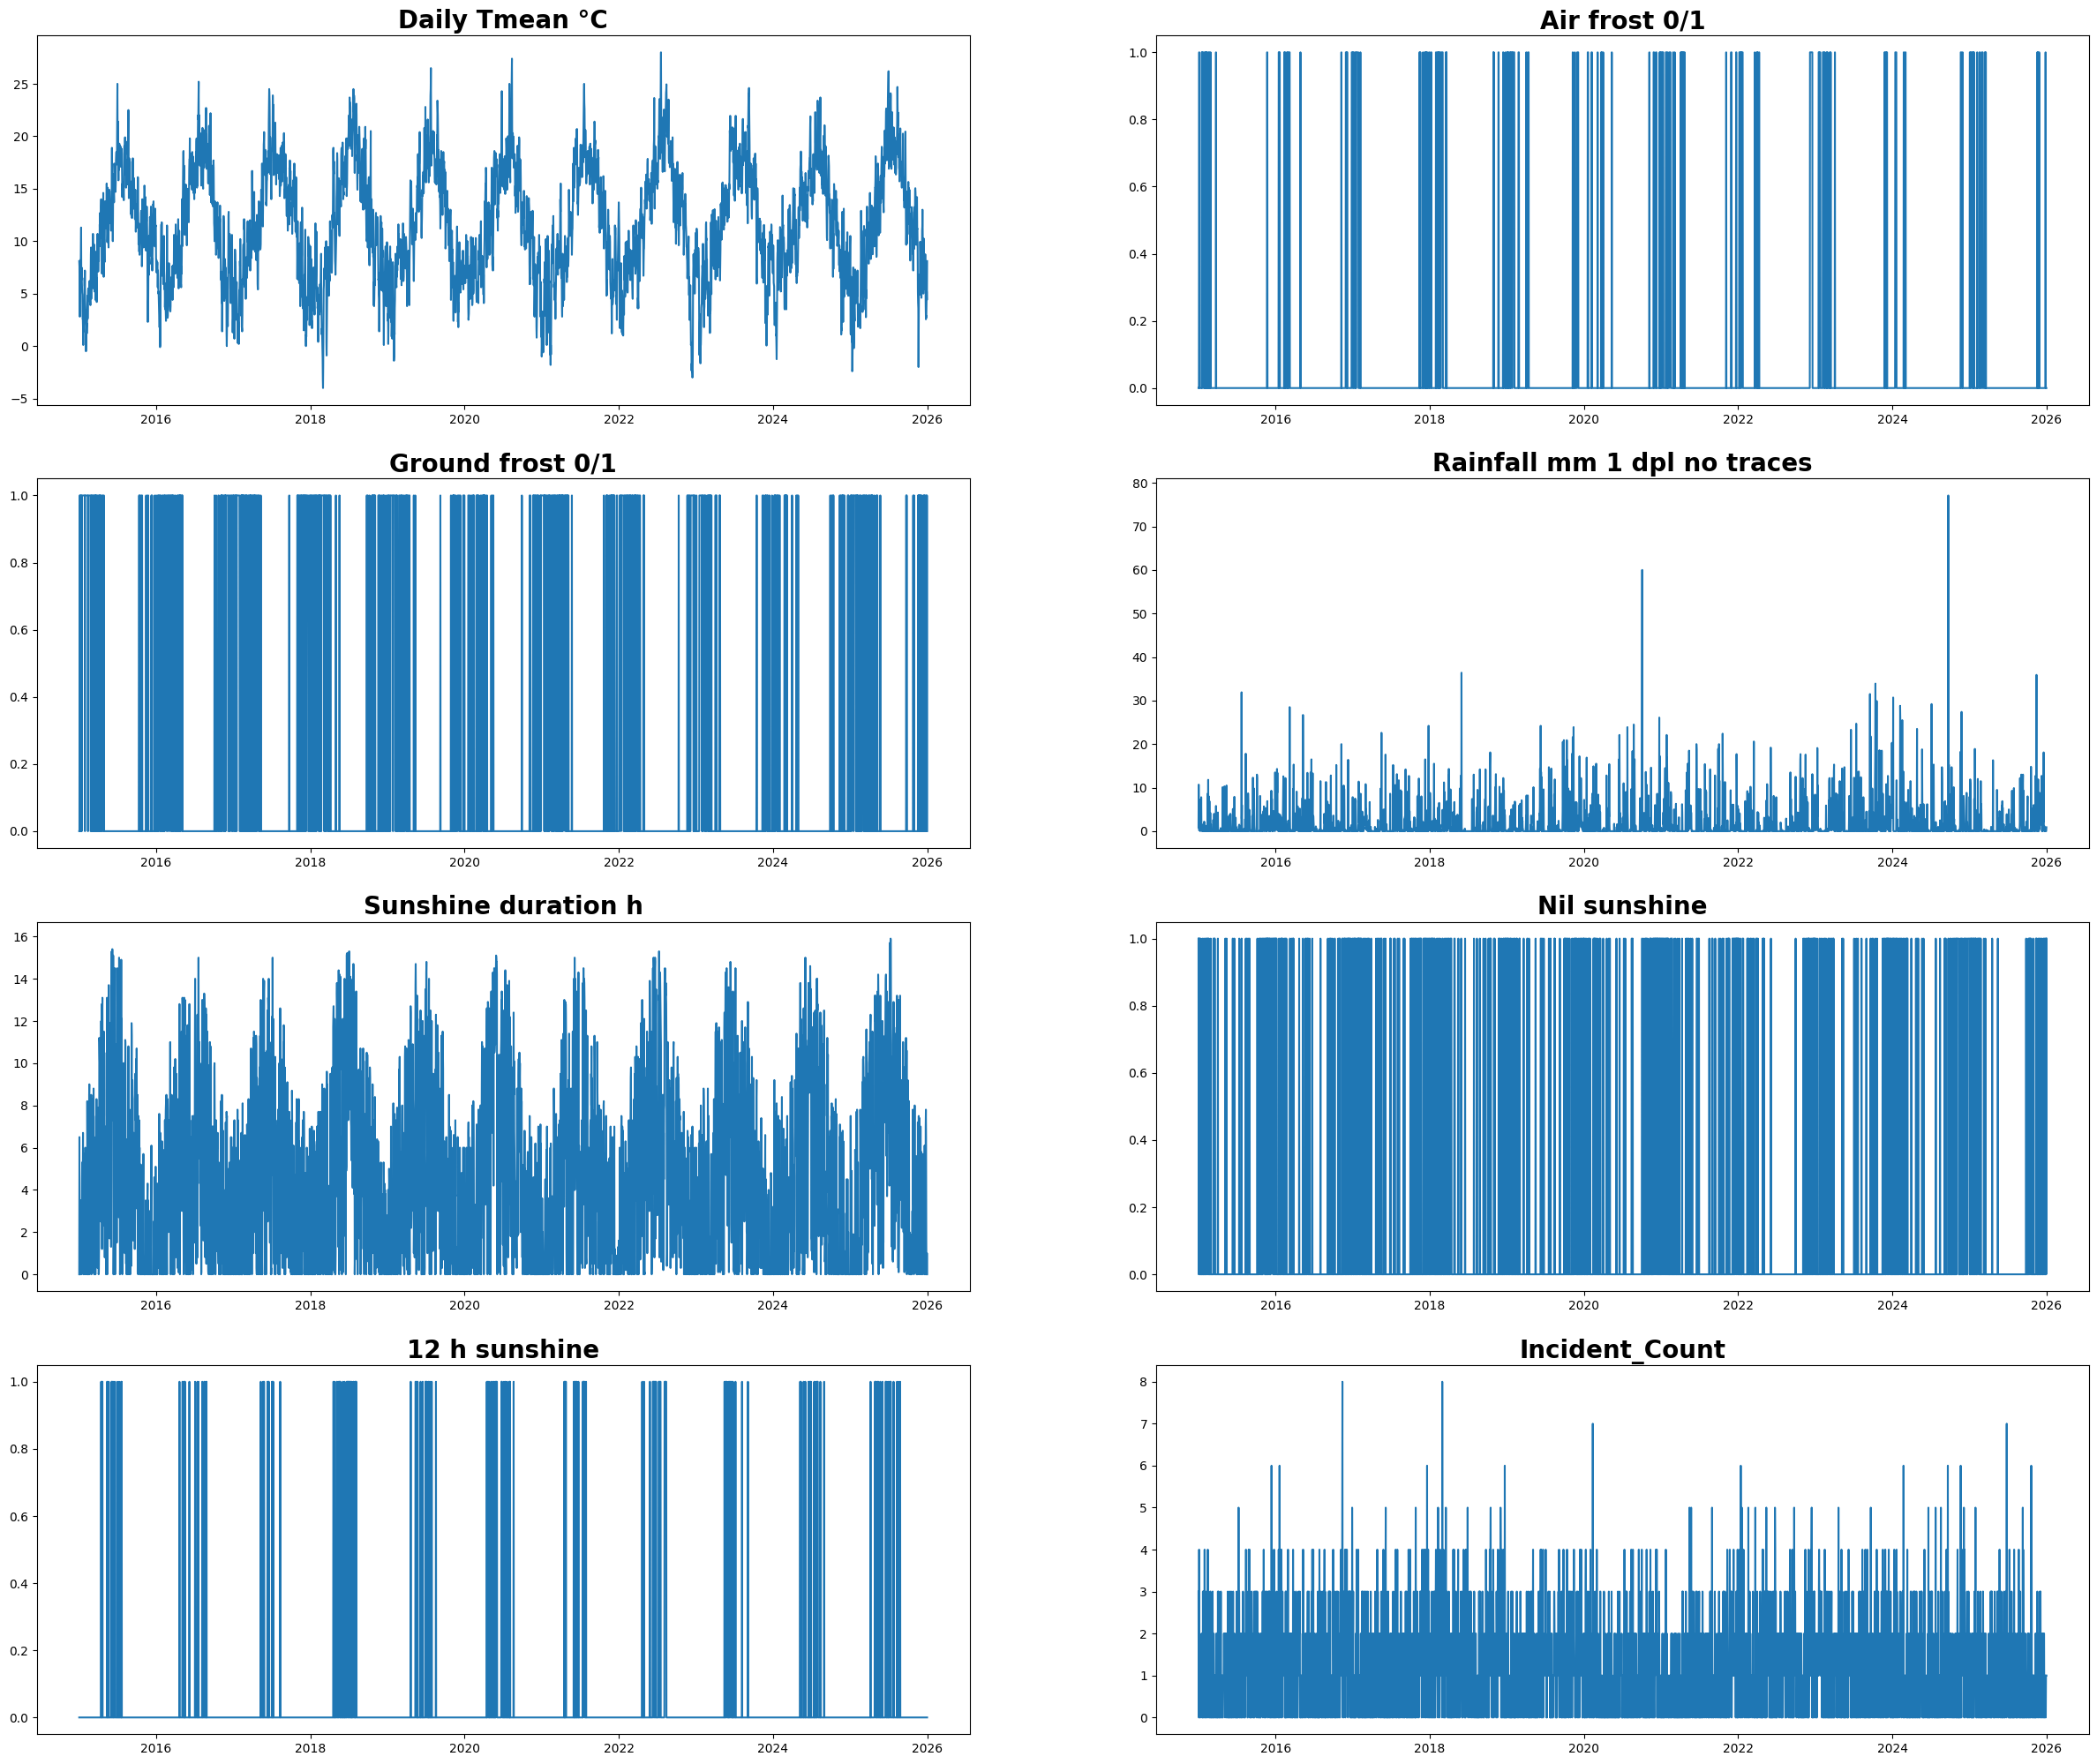

In [90]:
daily_total

daily_total_plot = plot_dataframe(daily_total.iloc[:,0:])

### As expected, the overall shape is extremely similar when considering the daily means or the daily totals. We can repeat this for the weekly data and present the mean values of the left and total values on the right. To do this, we define the below function plot_twodfs.

In [91]:
def plot_twodfs(dataframe1, dataframe2):
    """
    A function which plots the data from each dataframe side by side.
    This is such that column 0 of each dataframe will be side by side in row 0 of a 2x2 figure, and so on for all columns. 
    NOTE: Therefore dataframe1 and dataframe2 must have the same number of columns.
    """
    if dataframe1.shape[1] != dataframe2.shape[1]:
        print('Error: dataframe1 and dataframe2 must have the same number of columns')
        return
    
    n_rows = dataframe1.shape[1]
    n_cols = 2
    fig, axs = plt.subplots(n_rows, 2, figsize = (30, 25))
    
    columns1 = dataframe1.columns
    columns2 = dataframe2.columns
    
    for i in range(n_rows):
        axs[i, 0].plot(dataframe1[columns1[i]]);
        axs[i, 0].set_title('Dataframe1: '+ columns1[i], fontweight = 'bold', size = 20);

        axs[i, 1].plot(dataframe2[columns2[i]]);
        axs[i, 1].set_title('Dataframe2: '+ columns2[i], fontweight = 'bold', size = 20);
    # Show the plot
    plt.show()    
    
    return

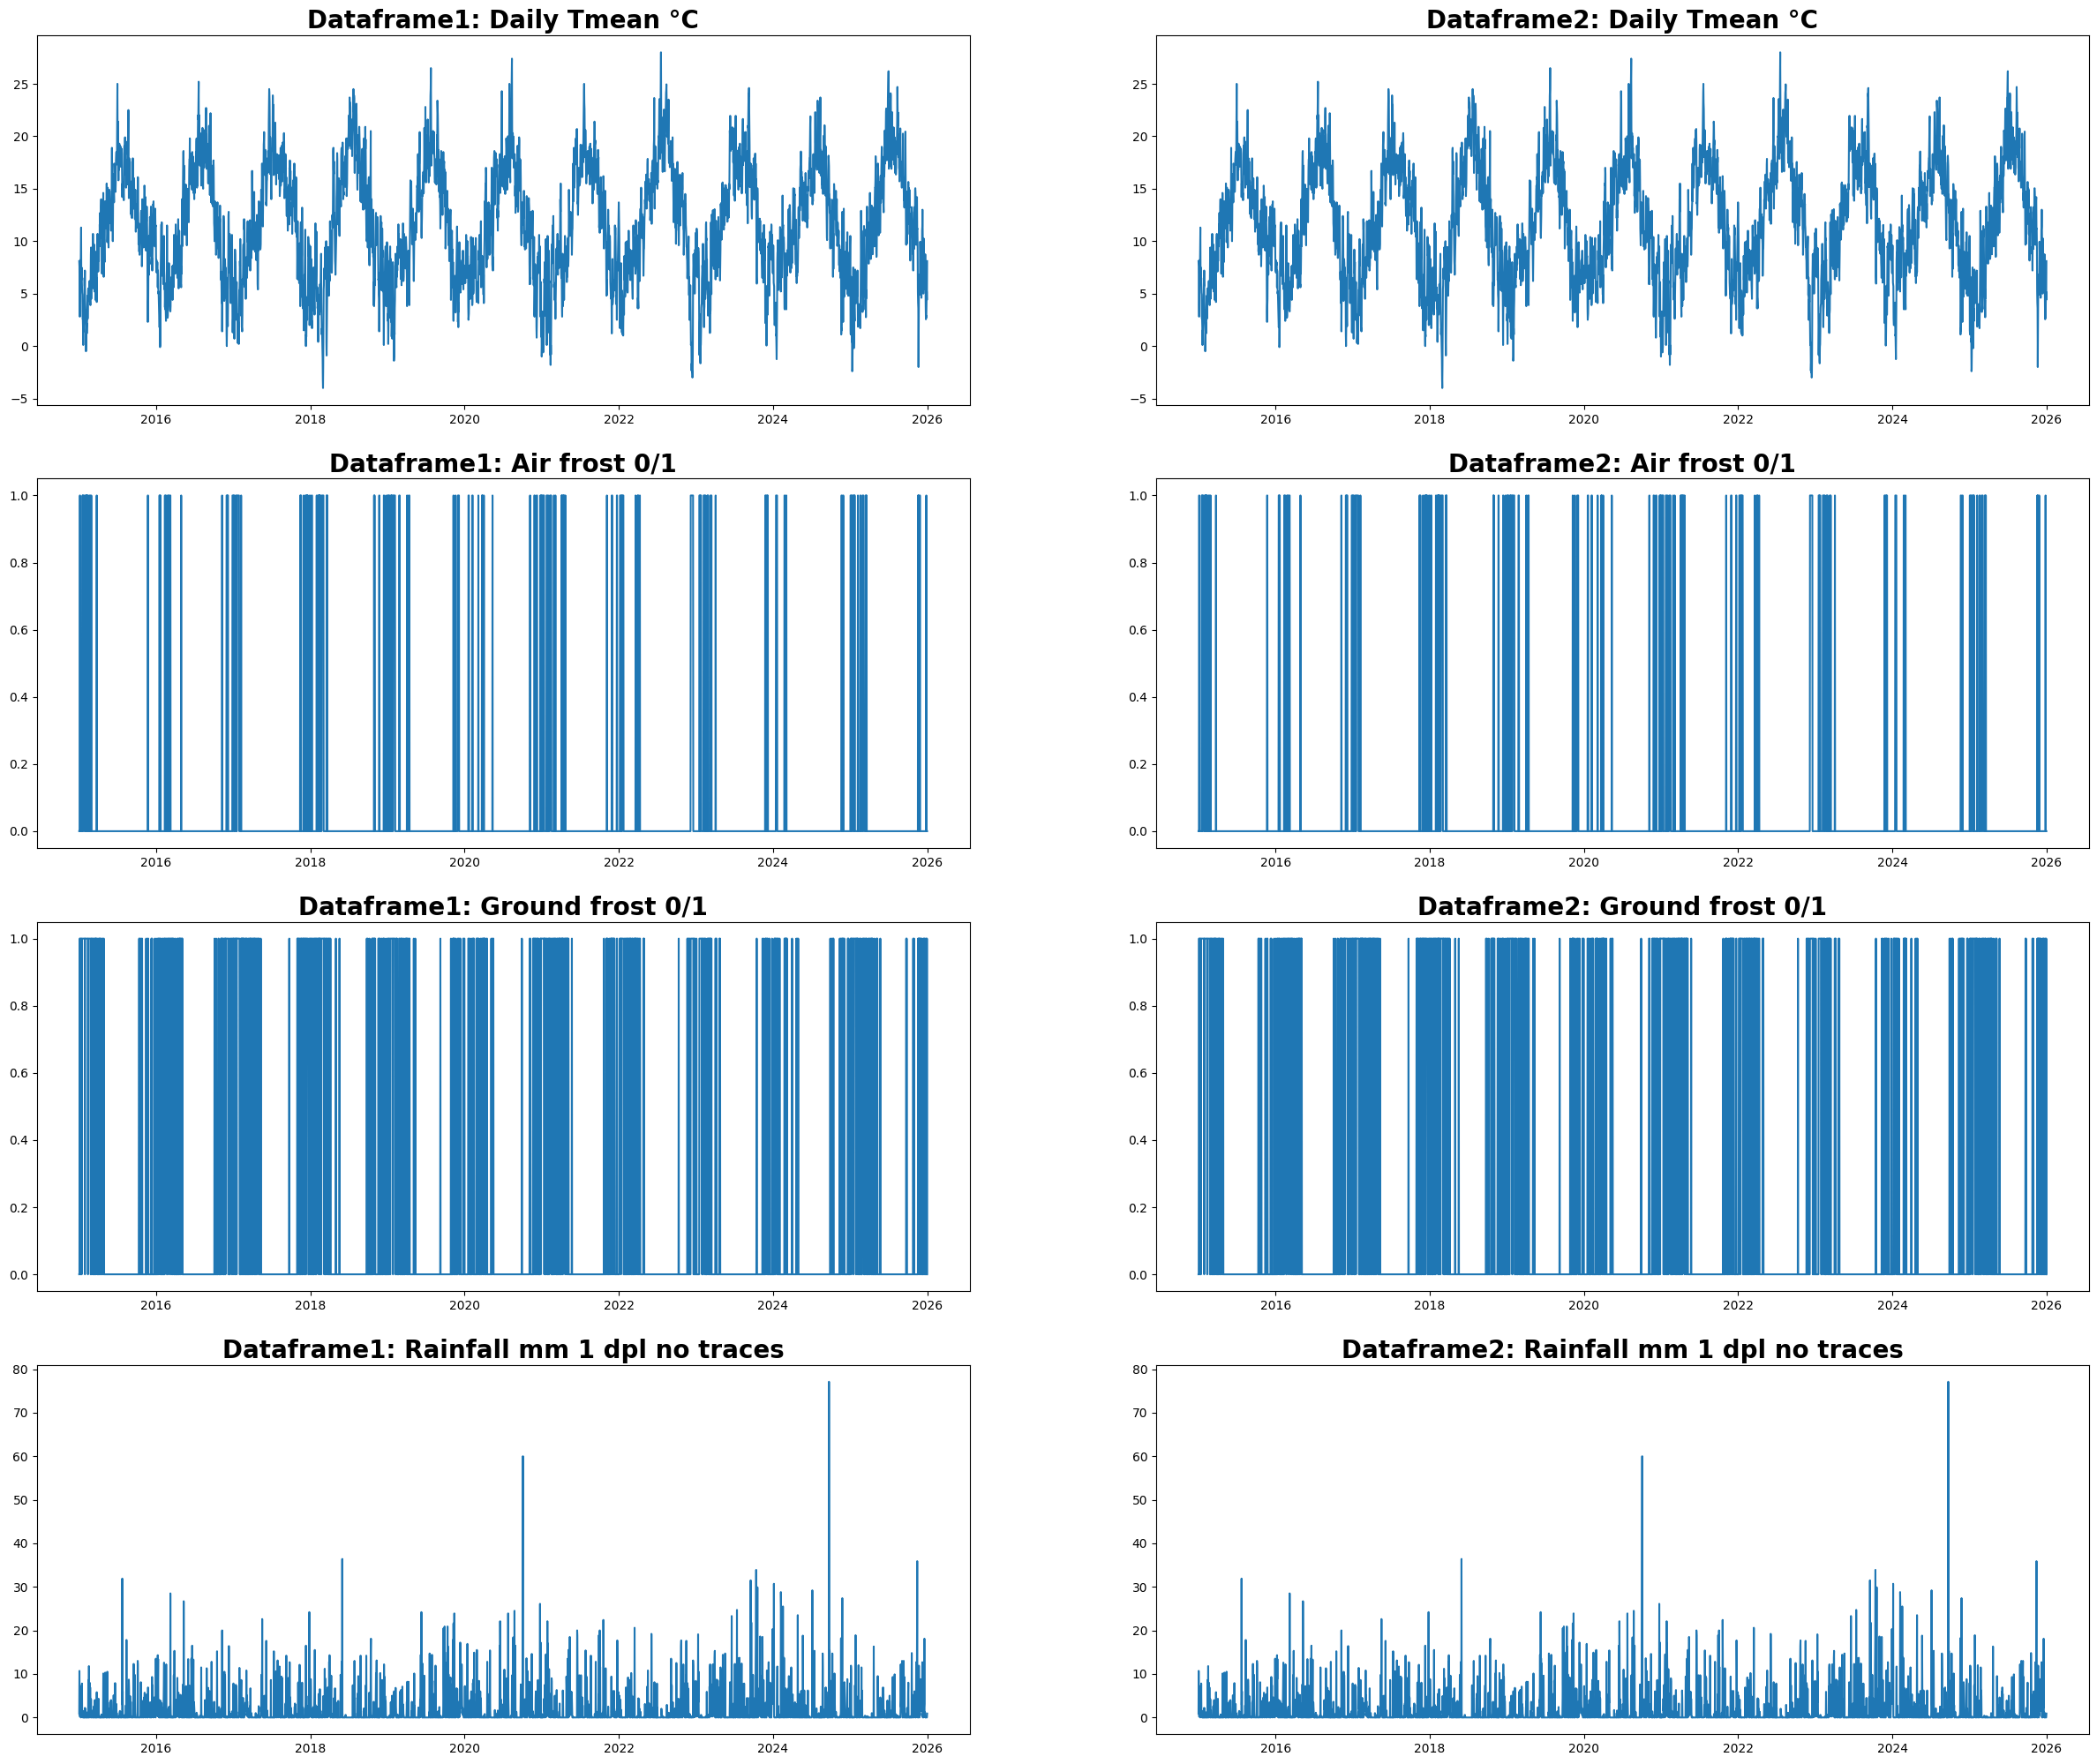

In [92]:
wmt = plot_twodfs(daily_mean.iloc[:,0:4], daily_total.iloc[:,0:4])

In [133]:
# Add your code below
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(daily_mean['Incident_Count']
                           , model='additive'
                           , period=52
                           ,two_sided=True, extrapolate_trend=0
                           )


trend = result.trend
seasonal = result.seasonal
residual = result.resid


In [134]:
def plot_decomposition(original, trend, seasonal, residual):
    """
    Plot the components of a decomposition. Pass in the original univarate data which was decomposed, and then the 
    3 resulting components, being the trend, seasonal and residual parts. 
    """
    # Plot the results
    plt.subplot(411)
    plt.plot(original, label = 'Original');
    plt.legend(loc = 'best')
    
    plt.subplot(412)
    plt.plot(trend, label = 'Trend');
    plt.legend(loc = 'best')
    
    plt.subplot(413)
    plt.plot(seasonal, label = 'Seasonality');
    plt.legend(loc = 'best')
    
    plt.subplot(414)
    plt.plot(residual, label = 'Residuals');
    
    plt.legend(loc = 'best')
    plt.tight_layout()
    plt.show()
    return

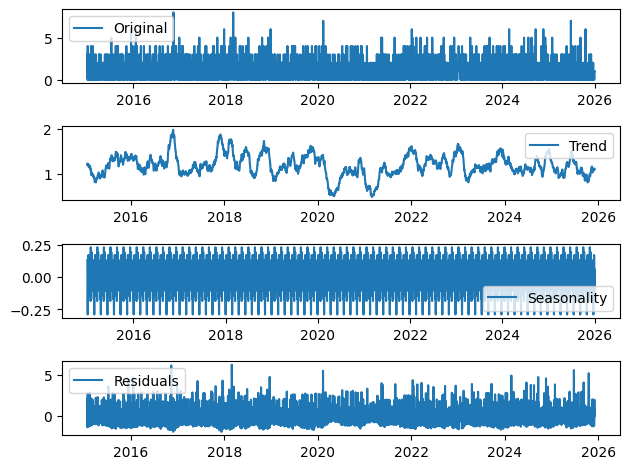

In [135]:
seasonality_plot = plot_decomposition(daily_mean['Incident_Count'], trend, seasonal, residual)

### Stationarity for Multivariate Time Series

Recall that stationarity is an important feature of time series data and that a stationary time series has properties that do not depend on time. In particular, the mean and variance are independent of time.

As in the univariate case, when looking at multivariate data, we need each column to be a stationary time series in order to be able to apply many common time series models.

To do this, we use the Augmented Dickey-Fuller test, which is a statistical test for stationarity.

8. Write a function, adf_test which does the following:

Takes in input of a column of a dataframe, df_col.

Define dftest to be the result of applying the function adfuller() to df_col.

Set p to store the p-value. This will be contained as one of the entries in the dftest tuple.

Creates the variable result in the following way: if p<=0.05 it contains the string "column_name is stationary", otherwise contains the string "column_name is not stationary".

returns result

One example of an accepted output is the following: 'Global_active_power is stationary'

Note: The Augmented Dickey-Fuller test generates a tuple consisting of 6 parameters:

the ADF test statistic
the p-value
number of lags used
number of observations used
critical values at 1%, 5%, 10% levels
the maximized information criterion (icbest).
Hint: to get the column name you can use df_col.name

In [96]:
from statsmodels.tsa.stattools import adfuller

df_test = adfuller(daily_mean['Incident_Count'])
df_test[0]

np.float64(-14.521797774070308)

In [97]:
from statsmodels.tsa.stattools import adfuller
# Add your code below

def adf_test(df_col):
    dftest = adfuller(df_col)
    adf_stat = df_test[0]
    p = dftest[1]
    if p <= 0.05:
        result = f"{df_col.name}: is stationary"
    else:
        result = f"{df_col.name}: is NOT stationary"
    return result

In [98]:
for i in range(daily_mean.shape[1]):
     print(adf_test(daily_mean.iloc[:,i]))

Daily Tmean °C: is stationary
Air frost 0/1: is stationary
Ground frost 0/1: is stationary
Rainfall mm 1 dpl no traces: is stationary
Sunshine duration h: is stationary
Nil sunshine: is stationary
12 h sunshine: is stationary
Incident_Count: is stationary


### Cross correlation

The final aspect we need to consider before building our model is the correlations amongst features. There are several ways to consider the correlation between time series including Pearson correlation, Spearman correlation, and cross-correlation functions.

Note that when two time series variables are non-stationary, they may show strong correlation even through the underlying processes have no casual relationships. This strong correlation may be purely caused by the fact that the two time series variables have non-constant mean. This phenomenon is called spurious relationship and is worth considering in the non-stationary case.

For extra material on quantifying correlation see the link here.

### SPEARMAN ASSESMENT:
Monotonic Association: Measures if variables increase/decrease together, even if not linearly. Rank-Based: Ranks data from low to high, calculating Pearson’s correlation on these ranks.

In [99]:
daily_corr = daily_mean.corr(method = 'spearman')
daily_corr

,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Rainfall mm 1 dpl no traces,Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Daily Tmean °C,1.000000,-0.445094,-0.635861,-0.106666,0.355853,-0.247011,0.255967,-0.035012
Air frost 0/1,-0.445094,1.000000,0.533620,-0.051650,-0.051307,0.053500,-0.067775,0.033891
Ground frost 0/1,-0.635861,0.533620,1.000000,-0.061465,-0.037266,0.032220,-0.091125,0.044855
Rainfall mm 1 dpl no traces,-0.106666,-0.051650,-0.061465,1.000000,-0.404648,0.232771,-0.206537,0.037682
Sunshine duration h,0.355853,-0.051307,-0.037266,-0.404648,1.000000,-0.658729,0.420295,0.006112
Nil sunshine,-0.247011,0.053500,0.032220,0.232771,-0.658729,1.000000,-0.118563,0.006163
12 h sunshine,0.255967,-0.067775,-0.091125,-0.206537,0.420295,-0.118563,1.000000,-0.006970
Incident_Count,-0.035012,0.033891,0.044855,0.037682,0.006112,0.006163,-0.006970,1.000000


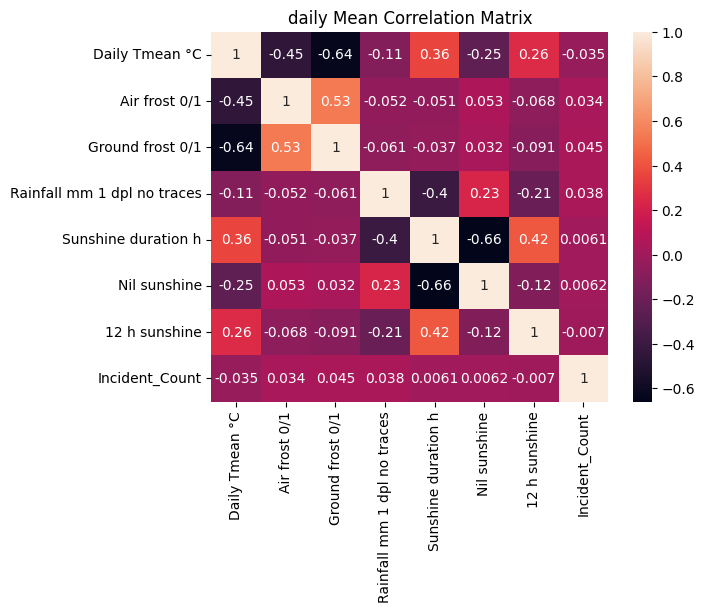

In [100]:
hm1 = sns.heatmap(daily_corr, annot=True,
         xticklabels=daily_mean.columns,
         yticklabels=daily_mean.columns);
hm1.set_title('daily Mean Correlation Matrix');

Building the Model: VAR
Vector autoregression (VAR) is a very flexible and easy to use model for the analysis of multivariate time series. It is an extension of the univariate AR model.

In a VAR model, each variable is a linear function of the past values of itself and the past values of all the other variables.

Consider the case of bivariate data, that is we have 2 time series of interest. Using 1 lag, VAR will model the following:


y1(t) = a1 + w11 * y1(t-1) + w12 y2(t-1) + e1(t-1)
and

y2(t) = a2 + w21 * y1(t-1) + w22 y2(t-1) + e2(t-1)
Here:

a1 and a2 are the constant terms,
w11, w12, w21, and w22 are the coefficients,
e1 and e2 are the error terms
This can be extended and written in matrix notation for lag up to p as:

y(t) = a + w1 * y(t-1) + ... + wp * y(t-p) + e(t), 
where now, y is a vector containing y1, y2, all the way up to yp, and w1 is a vector containing the values w11, w12, all the way up to wp. Lastly e is a vector containing all of the error terms.

You can find the documentation about the VAR model here.

We will now consider 3 types of forecasting problems as assess how the VAR model performs in each.

1) Predicting 1 week ahead based on all historical data. This is a fairly short-term forecast.

2) Predicting 2 months ahead based on all historical data. This is a much longer term forecast.

3) Multi-step forecast for 1 month. This involves making a prediction for one time step, taking the prediction, and feeding it into the model as an input in order to predict the subsequent time step. This process is repeated until the desired number of steps have been forecasted. In practice this can be very useful, especially in conjunction with other forecasts as it allows us to make full use of the current and updated data.

Predicting 1 week ahead.
10. Create a copy of the daily_mean dataframe and store it in model_ds.

In [101]:
model_ds = daily_mean.copy()
model_ds.head(2)

,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Rainfall mm 1 dpl no traces,Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,
2015-01-01,8.1,0.0,0.0,0.9,0.0,1.0,0.0,3.0
2015-01-02,7.6,0.0,0.0,10.7,6.5,0.0,0.0,0.0


11. Create two new DataFrames. The first one, ds_train1, with all the rows of model_ds except for the last 7. The second one, ds_test1, with only the last 7 rows of model_ds.

In [102]:
# Add your code below
ds_train1 = model_ds.iloc[:-365]
ds_train1.tail(2)

,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Rainfall mm 1 dpl no traces,Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,
2024-12-30,6.6,0.0,0.0,0.0,0.0,1.0,0.0,2.0
2024-12-31,9.6,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [103]:
ds_test1 = model_ds.iloc[-365:]
ds_test1.head(2)

,Daily Tmean °C,Air frost 0/1,Ground frost 0/1,Rainfall mm 1 dpl no traces,Sunshine duration h,Nil sunshine,12 h sunshine,Incident_Count
Date,,,,,,,,
2025-01-01,10.5,0.0,0.0,7.9,0.0,1.0,0.0,0.0
2025-01-02,1.5,1.0,1.0,0.1,7.5,0.0,0.0,1.0


## Using the function VAR, define the model using ds_train1. 

### Then fit via the .fit() function and define the result as model1_fit.

In [104]:
from statsmodels.tsa.api import VAR
# Define themodel:
model1 = VAR(ds_train1)
model1_fit = model1.fit()
model1_fit

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [105]:
print(model1_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 18, Sep, 2026
Time:                     16:09:09
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -4.17752
Nobs:                     3652.00    HQIC:                  -4.25627
Log likelihood:          -33532.2    FPE:                  0.0135710
AIC:                     -4.29982    Det(Omega_mle):       0.0133064
--------------------------------------------------------------------
Results for equation Daily Tmean °C
                                    coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------
const                                  0.007742         0.130051            0.060           0.953
L1.Daily Tmean °C                      0.983767         0.008832          111.390

Create an array prediction1 that contains the predictions on the 7 values of ds_test1.

You can use the forecast function with parameters model1_fit.endog, and steps as the length for which we wish to forecast.

Note: model1_fit.endog contains an np array of ds_train1 and so you can also use np.asarray(ds_train1).

In [106]:
steps = len(ds_test1)
prediction1 = model1_fit.forecast(y = model1_fit.endog, steps = steps)
# If you specifically need it as a numpy array explicitly
prediction1 = np.asarray(prediction1)
prediction1

array([[ 9.8778748 ,  0.0281705 ,  0.12426436, ...,  0.32205669,
         0.01879556,  1.24727191],
       [ 9.86691068,  0.0669771 ,  0.23688107, ...,  0.22791849,
         0.02837811,  1.2306393 ],
       [ 9.90900652,  0.0908229 ,  0.27784055, ...,  0.21098606,
         0.03573933,  1.21776253],
       ...,
       [11.58937068,  0.07761474,  0.22587792, ...,  0.17567465,
         0.0616771 ,  1.19404667],
       [11.58937068,  0.07761474,  0.22587792, ...,  0.17567465,
         0.0616771 ,  1.19404667],
       [11.58937068,  0.07761474,  0.22587792, ...,  0.17567465,
         0.0616771 ,  1.19404667]], shape=(365, 8))

You can notice that the prediction contains a large array of forecasts for each of the columns in our dataset. We are interested in column 0. Therefore we define the below function transform_prediction which converts the model forecast result to an array of univariate predictions for the Global_active_power.

In [107]:
def transform_prediction(prediction):
    return [prediction[i][0] for i in range(len(prediction))]

Using transform_prediction we convert the model forecast to predictions that we can compare to our test data. Uncomment the following cell to plot predictions_7day against the actual data.

In [108]:
predictions_7day = transform_prediction(prediction1)
predictions_7day

[np.float64(9.8778748007787),
 np.float64(9.86691068370972),
 np.float64(9.90900651543927),
 np.float64(9.988701268818234),
 np.float64(10.0829909297054),
 np.float64(10.18018219426935),
 np.float64(10.275027774042265),
 np.float64(10.365328664682028),
 np.float64(10.450291630246998),
 np.float64(10.529766131641061),
 np.float64(10.60388892941861),
 np.float64(10.672917983787029),
 np.float64(10.737155034606777),
 np.float64(10.796909931953747),
 np.float64(10.852484641199219),
 np.float64(10.904166496846031),
 np.float64(10.952225775874378),
 np.float64(10.996915261288178),
 np.float64(11.038470697178386),
 np.float64(11.077111618969395),
 np.float64(11.113042317886837),
 np.float64(11.146452828738044),
 np.float64(11.177519891391839),
 np.float64(11.206407865127343),
 np.float64(11.233269588443008),
 np.float64(11.258247183089159),
 np.float64(11.281472803844892),
 np.float64(11.303069336715273),
 np.float64(11.323151048633207),
 np.float64(11.341824191815494),
 np.float64(11.3591875

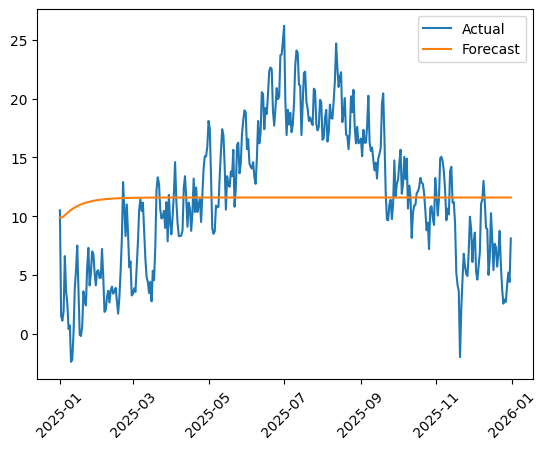

In [109]:
fig1 = plt.figure()
plt.plot(ds_test1.index, ds_test1.iloc[:,0], label='Actual');
plt.plot(ds_test1.index, predictions_7day, label='Forecast');
plt.xticks(rotation=45);
plt.legend();

In [156]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator != 0

    return np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]
    ) * 100

In [110]:
ds_test1['Incident_Count']

Date
2025-01-01    0.0
2025-01-02    1.0
2025-01-03    2.0
2025-01-04    2.0
2025-01-05    1.0
             ... 
2025-12-27    1.0
2025-12-28    0.0
2025-12-29    1.0
2025-12-30    1.0
2025-12-31    1.0
Name: Incident_Count, Length: 365, dtype: float64

In [111]:
from sklearn.metrics import mean_absolute_error
MAE1 = mean_absolute_error(y_true = ds_test1['Incident_Count'], y_pred = predictions_7day)
MAE1

10.4347952931005

In [138]:
MAPE1 = mean_absolute_percentage_error(y_true = ds_test1['Incident_Count'], y_pred = predictions_7day)
MAPE1

1.7913475283897328e+16

In [143]:
RMSE1 = mean_squared_error(SMAPE1)
RMSE1

110.12523938326336

In [158]:
SMAPE1 = smape(y_true = ds_test1['Incident_Count'], y_pred = predictions_7day )
print(SMAPE1)

168.2640451587665


## Predicting 2 months ahead.

Using the methodology given for the 1 week forecast, we will now predict 2 months ahead.

15. Create two new DataFrames. The first one, ds_train2, with all the rows of model_ds except for the last 60. The second one, ds_test2, with only the last 60 rows of model_ds.

In [112]:
ds_train2 = model_ds.iloc[:-60]
ds_test2 = model_ds.iloc[-60:]

## Create a variable named model2_fit where you store the VAR model fitted on ds_train2.

In [113]:
model2 = VAR(ds_train2)
model2_fit = model2.fit()
model2_fit

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [114]:
print(model2_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 18, Sep, 2026
Time:                     16:09:17
--------------------------------------------------------------------
No. of Equations:         8.00000    BIC:                   -4.19728
Nobs:                     3957.00    HQIC:                  -4.27106
Log likelihood:          -36315.4    FPE:                  0.0134120
AIC:                     -4.31161    Det(Omega_mle):       0.0131704
--------------------------------------------------------------------
Results for equation Daily Tmean °C
                                    coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------------------------
const                                 -0.012870         0.125358           -0.103           0.918
L1.Daily Tmean °C                      0.984058         0.008467          116.219

In [115]:
steps =len(ds_test2)
prediction2 = model2_fit.forecast(y = model2_fit.endog, steps = steps)
prediction2 = np.asarray(prediction2)

In [116]:
predictions_60day = transform_prediction(prediction2)

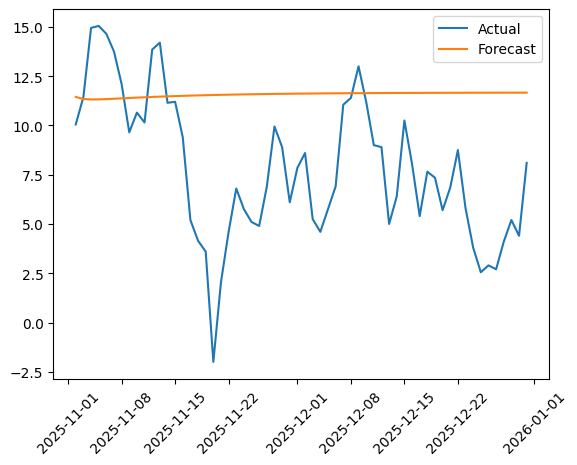

In [117]:
fig2 = plt.figure()
plt.plot(ds_test2.index, ds_test2.iloc[:,0], label='Actual');
plt.plot(ds_test2.index, predictions_60day, label='Forecast');
plt.xticks(rotation=45);
plt.legend();

In [118]:
MAE2 = mean_absolute_error(y_pred = predictions_60day , y_true =ds_test2['Incident_Count']  )
MAE2

10.518389610179126

In [139]:
MAPE2 = mean_absolute_percentage_error(y_pred = predictions_60day , y_true =ds_test2['Incident_Count']  )
MAPE2

1.648209821955881e+16

In [145]:
RMSE2 = mean_squared_error(y_pred = predictions_60day , y_true =ds_test2['Incident_Count']  )
RMSE2

111.40579231582313

In [159]:
SMAPE2 = smape(y_pred = predictions_60day , y_true =ds_test2['Incident_Count']  )

print(SMAPE2)

168.51022642996938


1 month multi-step forecast.
As stated previously, multi-step forecasting involves making a prediction for one time step, taking the prediction, and feeding it into the model as an input in order to predict the subsequent time step.

We repeat this process is until the we have forecasted the desired number of steps.

To read more about this, visit the article here.

19. Create a function ms_forecast which implements a multi-step forecast.

The input should be the dataframe, df, and the number of steps to forecast, n_obs.

Begin by setting preds to be an empty list.

The function should then contain a for loop that does the following:

1) Loop from i being 0 to n_obs

In the loop:

2) Define model to be a VAR model using the multivariate data, excluding the last n_obs-i values.

Note: In this way, when i is 0, we will exclude the last n_obs days and forecast 1 step, when i is 1, we will exclude only the last n_obs-1 days and forecast another step. And so on until we have all the data except the last value which we forecast.

3) Fit the model using .fit() and assign this to model_fit.

4) Create a prediction using .forecast with the model_fit.endog and 1 step.

Hint: the output of this will give you an array containing an array of 1-step forecasted values for all columns in our dataframe. As we are only interested in the first column, index the output of the forecast with [0][0].

5) Append the prediction to preds

The function should return preds.

In [119]:
model_ds.shape

(4018, 8)

In [120]:
def ms_forecast(df, n_obs):
    # create empty list
    preds = []
    for i in range(0, n_obs):
        # create training set
        df_train = df.iloc[:-n_obs+i]  
        print(df_train.shape[0])
        # initiate VAR with training set
        model = VAR(df_train)
        
        # fit training set data to model
        model_fit = model.fit()
        
        # create a forecast with one step ahead
        prediction = model_fit.forecast(y = model_fit.endog, steps = 1)
        
        # append predcition to preds
        ## As we are only interested in the first column -> 
        ### index the output of the forecast with [0][0]
        preds.append(prediction[0][0])
        df_train
        
    return preds

In [121]:
preds = ms_forecast(model_ds, 30)


3988
3989
3990
3991
3992
3993
3994
3995


C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\

3996
3997
3998
3999
4000
4001
4002
4003
4004
4005


C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\

4006
4007
4008
4009
4010
4011
4012
4013
4014


C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\

4015
4016
4017


C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


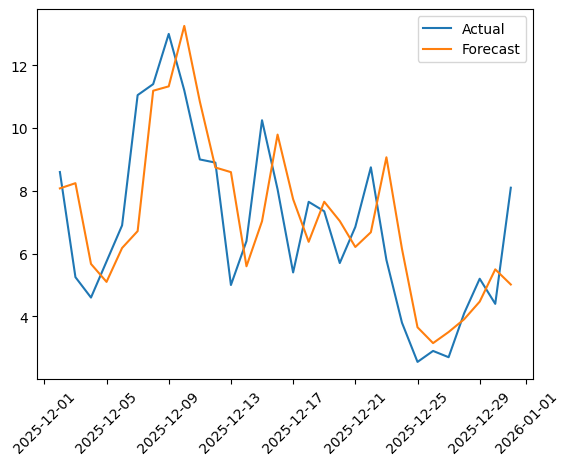

In [122]:
n_obs=30
fig3 = plt.figure()
plt.plot(model_ds.iloc[-n_obs:,0].index, model_ds.iloc[-n_obs:,0], label='Actual');
plt.plot(model_ds.iloc[-n_obs:,0].index, preds, label='Forecast');
plt.xticks(rotation=45);
plt.legend();

In [123]:
y_true = model_ds['Incident_Count'].iloc[-30:]
MAE3 = mean_absolute_error(y_true = model_ds['Incident_Count'].iloc[-30:], y_pred = preds)
MAE3

6.016339180070597

In [140]:
MAPE3 = mean_absolute_percentage_error(y_true = model_ds['Incident_Count'].iloc[-30:], y_pred = preds  )
MAPE3

9233346522585272.0

In [144]:
RMSE3 = mean_squared_error(y_true = model_ds['Incident_Count'].iloc[-30:], y_pred = preds  )
RMSE3

41.68717391811079

In [160]:
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    valid = denominator != 0

    return np.mean(
        np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]
    ) * 100



SMAPE3 = smape(y_true = model_ds['Incident_Count'].iloc[-30:], y_pred = preds )
SMAPE3


np.float64(149.429109869928)

In [161]:
MAE1, MAE2,MAE3

(10.4347952931005, 10.518389610179126, 6.016339180070597)

In [170]:
pd.DataFrame(data = [MAE1, MAE2, MAE3], index = ['MAE1', 'MAE2', 'MAE3'])

,0
MAE1,10.434795
MAE2,10.518390
MAE3,6.016339


In [169]:
pd.DataFrame(data = [MAPE1, MAPE2, MAPE3], index = ['MAPE1', 'MAPE2', 'MAPE3'])

,0
MAPE1,1.791348e+16
MAPE2,1.648210e+16
MAPE3,9.233347e+15


In [163]:
SMAPE1, SMAPE2, SMAPE3

(np.float64(168.2640451587665),
 np.float64(168.51022642996938),
 np.float64(149.429109869928))

In [171]:
pd.DataFrame(data = [SMAPE1, SMAPE2, SMAPE3], index = ['SMAPE1', 'SMAPE2', 'SMAPE3'])

,0
SMAPE1,168.264045
SMAPE2,168.510226
SMAPE3,149.429110
